The setup: 

A free particle is confined in a 2D region, with the walls having infinite potential.

Let us start with solving for the known analytic case, where a free particle is confined inside a rectangular box. We know that the energy of the particle is given by $E_{nm} = \pi^2(n^2/L_x^2 + m^2/L_y^2)$, where $n, m = 1, 2, \dots$ are the quantum numbers and $L_x, L_y$ are the dimensions of the box.

The first part of the code is going to be the solver of the Schrodinger equation, that uses a finite difference eigensolver. We will also have a plot function which plots the wavefunction, and the energy of the free particle, with respect to the boundaries.

**Conventions:** units with $\hbar^2/2m = 1$, so the problem is $-\nabla^2\psi = E\psi$ inside the region and $\psi = 0$ on and outside the wall. The region is a boolean *mask* on a uniform grid of spacing $h$; swapping the rectangle for a stadium later only means swapping the mask function.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh

# Uniform grid covering the bounding box [0, Lx] x [0, Ly], spacing h
def grid(Lx, Ly, h):
    x = np.arange(0, Lx + h, h)
    y = np.arange(0, Ly + h, h)
    return np.meshgrid(x, y, indexing="ij")

# Infinite potential barrier as a mask: True strictly inside the box, False on/outside the wall
def rectangle(X, Y, Lx, Ly):
    return (X > 0) & (X < Lx) & (Y > 0) & (Y < Ly)

# Stadium mask: all points within distance r of a horizontal segment of length a centred at (x0, y0),
# i.e. an a x 2r rectangle with a half-disc of radius r on each end.
# dx = horizontal distance past the end of the segment (0 inside the straight section).
def stadium(X, Y, a, r, x0, y0):
    dx = np.maximum(abs(X - x0) - a / 2, 0)
    return dx**2 + (Y - y0)**2 < r**2

# The stadium wall as a closed curve, for drawing on top of plots
def stadium_wall(a, r, x0, y0, npts=400):
    t = np.linspace(-np.pi / 2, np.pi / 2, npts)
    x = np.concatenate([x0 + a / 2 + r * np.cos(t), x0 - a / 2 - r * np.cos(t), [x0 + a / 2]])
    y = np.concatenate([y0 + r * np.sin(t), y0 - r * np.sin(t), [y0 - r]])
    return x, y

In [2]:
# Finite-difference eigensolver for -lap(psi) = E psi with psi = 0 outside the mask.
# Build the 5-point Laplacian on the whole box, then keep only the rows/columns of interior
# points: dropping the wall points from the stencil is exactly the Dirichlet condition psi = 0.
def solve(mask, h, k):
    nx, ny = mask.shape
    d2 = lambda n: sp.diags([1, -2, 1], [-1, 0, 1], shape=(n, n))
    lap = (sp.kron(d2(nx), sp.eye(ny)) + sp.kron(sp.eye(nx), d2(ny))).tocsr() / h**2
    idx = np.flatnonzero(mask)
    H = -lap[idx][:, idx]
    E, v = eigsh(H, k=k, sigma=0, which="LM")   # shift-invert: the k lowest energies
    psi = np.zeros((k, nx * ny))
    psi[:, idx] = v.T / h                         # normalized so sum |psi|^2 h^2 = 1
    return E, psi.reshape(k, nx, ny)

# Analytic energies E_nm = pi^2 (n^2/Lx^2 + m^2/Ly^2), lowest k, with their quantum numbers
def energy(Lx, Ly, k, nmax=50):
    n, m = np.meshgrid(np.arange(1, nmax), np.arange(1, nmax), indexing="ij")
    E = np.pi**2 * (n**2 / Lx**2 + m**2 / Ly**2)
    order = np.argsort(E, axis=None)[:k]
    return E.ravel()[order], n.ravel()[order], m.ravel()[order]

In [3]:
# Irrational aspect ratio (golden ratio) so there are no accidental degeneracies n^2 + m^2
Lx, Ly, h, k = 1.0, (1 + 5**0.5) / 2, 0.01, 30

X, Y = grid(Lx, Ly, h)
mask = rectangle(X, Y, Lx, Ly)
E, psi = solve(mask, h, k)
E_exact, n, m = energy(Lx, Ly, k)

# Check 1: the 5-point matrix has a known exact spectrum, 4/h^2 [sin^2(n pi h/2Lx') + sin^2(m pi h/2Ly')],
# where Lx', Ly' = (interior points + 1) h is the box the grid actually sees. Must agree to machine precision.
Lx_grid, Ly_grid = (mask.any(1).sum() + 1) * h, (mask.any(0).sum() + 1) * h
nn, mm = np.meshgrid(np.arange(1, 100), np.arange(1, 100), indexing="ij")
E_disc = np.sort((4 / h**2 * (np.sin(nn * np.pi * h / (2 * Lx_grid))**2
                              + np.sin(mm * np.pi * h / (2 * Ly_grid))**2)).ravel())[:k]
print(f"max rel. error vs discrete spectrum:  {np.max(abs(E - E_disc) / E_disc):.1e}")

# Check 2: against the continuum E_nm the error should shrink as h -> 0. It is O(h), not O(h^2),
# because the wall at Ly = 1.618... falls between grid points (the "staircase" error).
for hh in [0.04, 0.02, 0.01, 0.005]:
    Xh, Yh = grid(Lx, Ly, hh)
    Eh, _ = solve(rectangle(Xh, Yh, Lx, Ly), hh, k)
    print(f"h = {hh:<6} max rel. error vs analytic E_nm: {np.max(abs(Eh - E_exact) / E_exact):.2e}")

# Check 3: wavefunctions are normalized
print("norm of psi_0:", (psi[0]**2).sum() * h**2)

max rel. error vs discrete spectrum:  7.7e-14
h = 0.04   max rel. error vs analytic E_nm: 5.22e-02
h = 0.02   max rel. error vs analytic E_nm: 1.00e-02


h = 0.01   max rel. error vs analytic E_nm: 4.25e-03


h = 0.005  max rel. error vs analytic E_nm: 2.81e-03
norm of psi_0: 1.0000000000000009


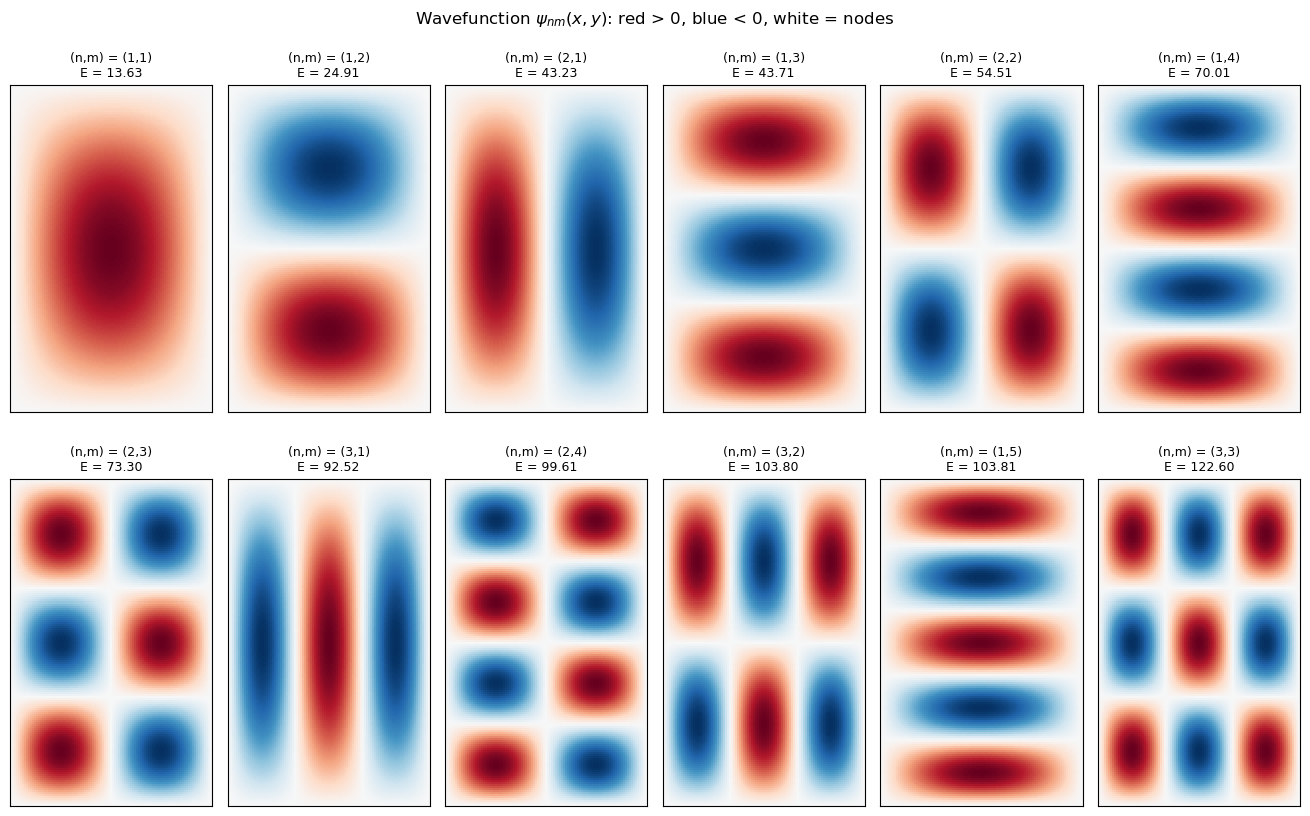

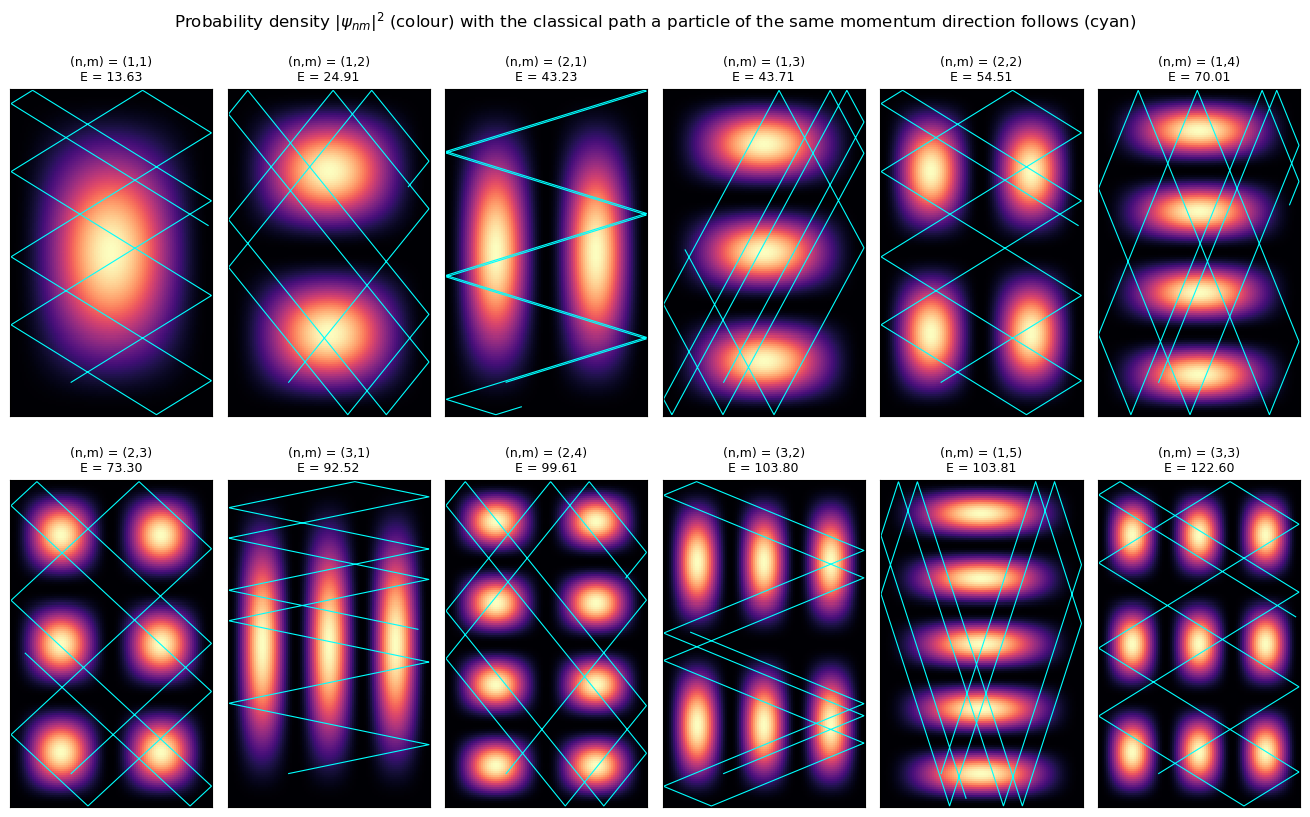

In [4]:
# Plot the eigenstates labelled by the matching analytic (n, m).
# density=False: signed psi (red +, blue -, white = nodes).  density=True: probability |psi|^2.
# orbits: optional list of (x, y) classical trajectories to draw on top of each panel.
# mask: grey out the region outside the wall.  wall: (x, y) outline of the wall, drawn in white.
def plot_wavefunction(X, Y, psi, E, title, suptitle="", density=False, orbits=None, mask=None, wall=None):
    cols = 6
    rows = int(np.ceil(len(psi) / cols))
    aspect = np.ptp(Y) / np.ptp(X)
    fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, (2.2 * aspect + 0.8) * rows))
    for i, (ax, p, e, t) in enumerate(zip(axes.flat, psi, E, title)):
        if mask is not None:
            p = np.ma.masked_where(~mask, p)
        if density:
            ax.pcolormesh(X, Y, p**2, cmap=plt.cm.magma.with_extremes(bad="0.75"), shading="auto")
        else:
            vmax = abs(p).max()
            ax.pcolormesh(X, Y, p, cmap=plt.cm.RdBu_r.with_extremes(bad="0.75"), vmin=-vmax, vmax=vmax, shading="auto")
        if wall is not None:
            ax.plot(*wall, color="white", lw=1)
        if orbits is not None and orbits[i] is not None:
            ax.plot(*orbits[i], color="cyan", lw=0.8)
        ax.set_title(f"{t}\nE = {e:.2f}", fontsize=9)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes.flat[len(psi):]:
        ax.axis("off")
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    plt.show()

# Classical billiard orbit in the rectangle with the momentum direction of state (n, m):
# psi_nm is a sum of plane waves with k = (+-n pi/Lx, +-m pi/Ly), so the ball moves along (n/Lx, m/Ly)
# and reflects off the walls. Reflections = unfold the motion and fold back with a triangle wave.
# It closes (is periodic) only if (m Lx^2)/(n Ly^2) is rational -- never here, since Ly/Lx is irrational.
def rect_orbit(Lx, Ly, n, m, x0, y0, bounces, npts=4000):
    v = np.array([n / Lx, m / Ly]) / np.hypot(n / Lx, m / Ly)
    t = np.linspace(0, bounces / (v[0] / Lx + v[1] / Ly), npts)   # wall hits per unit time = vx/Lx + vy/Ly
    fold = lambda s, L: L - abs(L - s % (2 * L))
    return fold(x0 + v[0] * t, Lx), fold(y0 + v[1] * t, Ly)

N = 12
labels = [f"(n,m) = ({a},{b})" for a, b in zip(n[:N], m[:N])]
plot_wavefunction(X, Y, psi[:N], E[:N], labels,
                  suptitle=r"Wavefunction $\psi_{nm}(x,y)$: red > 0, blue < 0, white = nodes")
orbits = [rect_orbit(Lx, Ly, a, b, 0.3 * Lx, 0.1 * Ly, bounces=12) for a, b in zip(n[:N], m[:N])]
plot_wavefunction(X, Y, psi[:N], E[:N], labels, density=True, orbits=orbits,
                  suptitle=r"Probability density $|\psi_{nm}|^2$ (colour) with the classical path a particle of the same momentum direction follows (cyan)")

## The stadium

Straight section of length $a = 2$ between two half discs of radius $r = 1$ (the standard Bunimovich stadium, which is fully chaotic). There is no analytic spectrum, so the checks are:

- **Weyl's law:** the number of states below $E$ is $N(E) \approx \frac{A}{4\pi}E - \frac{P}{4\pi}\sqrt{E}$, where $A$ is the area and $P$ the perimeter. This holds for *any* shape, so it tests the solver and the mask together.
- **Inverse participation ratio:** $I = \sum_i |\psi_i|^4 h^2$. I report $I\cdot A$, which is 1 for a perfectly flat state. Useful reference values are **2.25** for a rectangle eigenstate ($\langle\sin^4\rangle/\langle\sin^2\rangle^2 = 3/2$ per direction) and **3** for a random superposition of plane waves (Gaussian statistics, i.e. a perfectly ergodic state). States well above 3 are concentrated on a smaller region, which makes them scar candidates.

In [5]:
a, r, h_s, k_s = 2.0, 1.0, 0.015, 300
pad = 0.2                                   # empty margin between the stadium and the box
A, P = 2 * a * r + np.pi * r**2, 2 * a + 2 * np.pi * r

Lx_s, Ly_s = a + 2 * r + 2 * pad, 2 * r + 2 * pad   # rectangular box containing the stadium
Xs, Ys = grid(Lx_s, Ly_s, h_s)
mask_s = stadium(Xs, Ys, a, r, Lx_s / 2, Ly_s / 2)
wall_s = stadium_wall(a, r, Lx_s / 2, Ly_s / 2)
E_s, psi_s = solve(mask_s, h_s, k_s)

# Check 1: area of the mask vs the true stadium area (the staircase boundary costs O(h))
print(f"mask area {mask_s.sum() * h_s**2:.4f}  vs  exact {A:.4f}")

# Check 2: Weyl's law -- the counting function should track the smooth formula
N_weyl = A * E_s / (4 * np.pi) - P * np.sqrt(E_s) / (4 * np.pi)
for i in [49, 149, 299]:
    print(f"state {i + 1:>3}:  E = {E_s[i]:7.2f},  Weyl N(E) = {N_weyl[i]:6.1f}")

mask area 7.1314  vs  exact 7.1416
state  50:  E =  101.05,  Weyl N(E) =   49.2
state 150:  E =  286.56,  Weyl N(E) =  149.0
state 300:  E =  555.08,  Weyl N(E) =  296.2


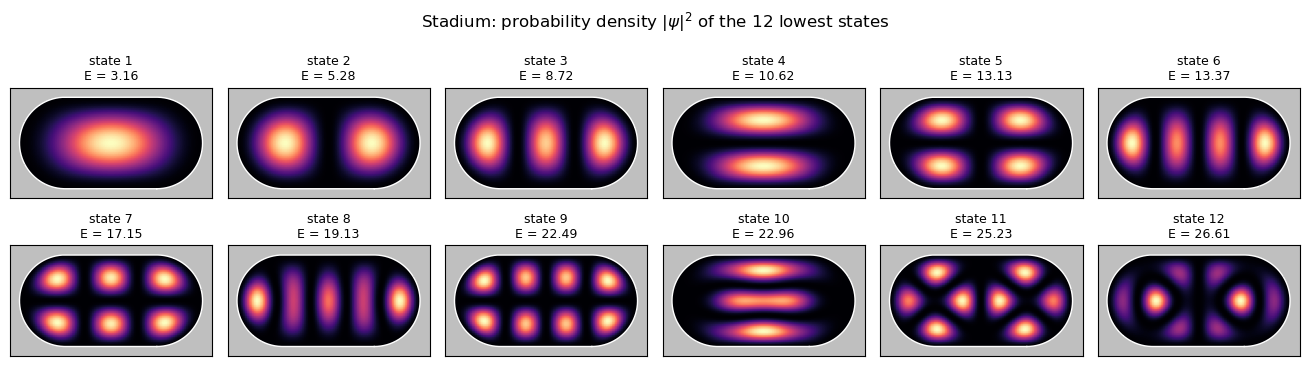

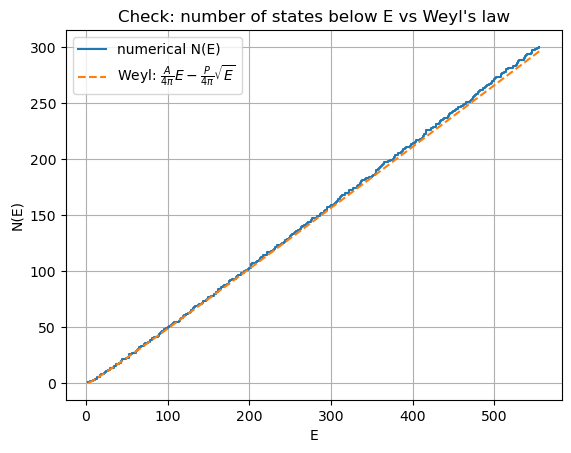

In [6]:
# Lowest 12 stadium states
N = 12
plot_wavefunction(Xs, Ys, psi_s[:N], E_s[:N], [f"state {i + 1}" for i in range(N)], density=True, mask=mask_s, wall=wall_s,
                  suptitle=r"Stadium: probability density $|\psi|^2$ of the 12 lowest states")

# Weyl staircase
plt.step(E_s, np.arange(1, k_s + 1), where="post", label="numerical N(E)")
plt.plot(E_s, N_weyl, "--", label=r"Weyl: $\frac{A}{4\pi}E - \frac{P}{4\pi}\sqrt{E}$")
plt.xlabel("E"); plt.ylabel("N(E)"); plt.title("Check: number of states below E vs Weyl's law")
plt.legend(); plt.grid()
plt.show()

I*A: mean 2.73, min 2.15, max 3.24
flat state: I*A = 1.0014


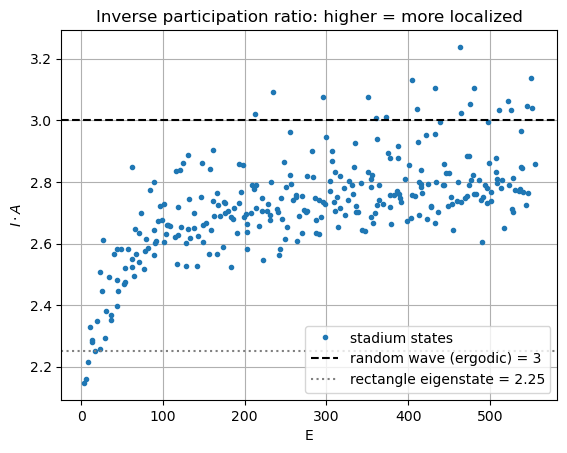

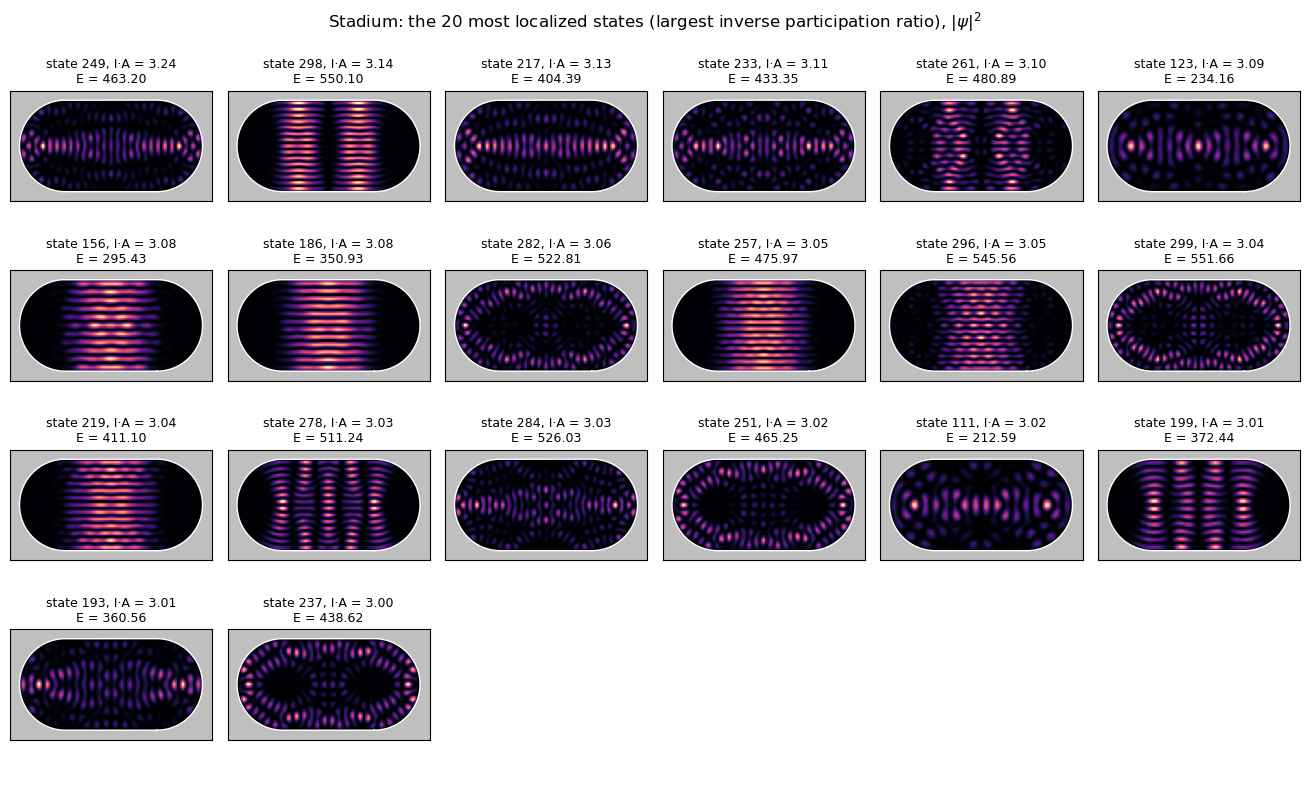

In [7]:
# Localization of the 20 most localized states: scar candidates

# Inverse participation ratio I = sum |psi|^4 h^2, in units of 1/A so that a flat state gives 1,
# a rectangle eigenstate 2.25 and an ergodic (random-wave) state 3. Larger = more localized.
def localized(psi, h, A):
    return (psi**4).sum(axis=(1, 2)) * h**2 * A

ipr = localized(psi_s, h_s, A)
print(f"I*A: mean {ipr.mean():.2f}, min {ipr.min():.2f}, max {ipr.max():.2f}")

# Check: a flat state over the mask must give I*A = 1 (up to the staircase area error)
flat = mask_s / np.sqrt(mask_s.sum() * h_s**2)
print(f"flat state: I*A = {localized(flat[None], h_s, A)[0]:.4f}")

plt.plot(E_s, ipr, ".", label="stadium states")
plt.axhline(3, color="k", ls="--", label="random wave (ergodic) = 3")
plt.axhline(2.25, color="gray", ls=":", label="rectangle eigenstate = 2.25")
plt.xlabel("E"); plt.ylabel(r"$I \cdot A$"); plt.title("Inverse participation ratio: higher = more localized")
plt.legend(); plt.grid()
plt.show()

N = 20
top = np.argsort(ipr)[::-1][:N]
plot_wavefunction(Xs, Ys, psi_s[top], E_s[top], [f"state {i + 1}, I·A = {ipr[i]:.2f}" for i in top],
                  density=True, mask=mask_s, wall=wall_s,
                  suptitle=rf"Stadium: the {N} most localized states (largest inverse participation ratio), $|\psi|^2$")

## Periodic orbits on the scarred states

Short periodic orbits of the stadium, each written as its list of bounce points:

- **horizontal**: 2 bounces, along the long axis between the two caps
- **diamond**: 4 bounces, cap ends and the midpoints of the flat walls
- **rectangle**: 4 bounces, at $\pm 45^\circ$ on each cap
- **bow-tie**: 4 bounces at angle $\pm\theta$ on each cap, crossing at the centre. $\theta$ is found by root-finding the reflection law.
- **bouncing ball**: a *family* of vertical bounces between the flat walls, marginally stable rather than isolated, so not a true scar orbit

**Check:** at every bounce the outgoing direction must be the mirror image of the incoming one about the wall normal, $\hat d_{out} = \hat d_{in} - 2(\hat d_{in}\cdot\hat n)\hat n$.

**Matching a state to an orbit:** take the tube of points within half a wavelength, $\pi/\sqrt{E}$, of the orbit. The enhancement is the probability inside the tube divided by the tube's share of the area: 1 for an evenly spread state, larger if $|\psi|^2$ piles up on the orbit. A state counts as a bouncing-ball state if more than 80% of its probability is in the straight section (an evenly spread state has 56%).

In [8]:
from scipy.optimize import brentq

x0, y0 = Lx_s / 2, Ly_s / 2
cap = lambda s, th: np.array([x0 + s * (a / 2 + r * np.cos(th)), y0 + r * np.sin(th)])   # s = +1 right cap, -1 left

# Outward unit normal of the stadium wall at a wall point p
def wall_normal(p):
    dx = p[0] - x0
    if abs(dx) <= a / 2 + 1e-12:
        return np.array([0.0, np.sign(p[1] - y0)])
    return (p - np.array([x0 + np.sign(dx) * a / 2, y0])) / r

# At each bounce: cross and dot product of the mirror-reflected incoming direction with the actual outgoing one.
# A valid orbit has cross = 0 and dot = 1 at every vertex.
def reflection_law(V):
    V = np.asarray(V, float)
    d_in = V - np.roll(V, 1, 0);  d_in /= np.linalg.norm(d_in, axis=1)[:, None]
    d_out = np.roll(V, -1, 0) - V;  d_out /= np.linalg.norm(d_out, axis=1)[:, None]
    n_ = np.array([wall_normal(p) for p in V])
    d_ref = d_in - 2 * (d_in * n_).sum(1)[:, None] * n_
    return d_ref[:, 0] * d_out[:, 1] - d_ref[:, 1] * d_out[:, 0], (d_ref * d_out).sum(1)

bowtie = lambda th: [cap(1, th), cap(-1, -th), cap(-1, th), cap(1, -th)]
th_b = brentq(lambda th: reflection_law(bowtie(th))[0][0], 0.1, 1.5)

orbits_s = {
    "horizontal": [cap(1, 0), cap(-1, 0)],
    "diamond":    [cap(1, 0), (x0, y0 + r), cap(-1, 0), (x0, y0 - r)],
    "rectangle":  [cap(1, np.pi / 4), cap(-1, np.pi / 4), cap(-1, -np.pi / 4), cap(1, -np.pi / 4)],
    "bow-tie":    bowtie(th_b),
}
print(f"bow-tie bounce angle: {np.degrees(th_b):.4f} deg")
for name, V in orbits_s.items():
    cross, dot = reflection_law(V)
    print(f"{name:<11} max |cross| = {abs(cross).max():.1e},  min dot = {dot.min():.6f}")

# Closed orbit as (x, y) for plotting; bouncing-ball family drawn as vertical lines (NaN-separated)
closed = lambda V: tuple(np.vstack([V, V[:1]]).T)
xb = np.linspace(x0 - a / 2, x0 + a / 2, 7)
bouncing_ball = (np.repeat(xb, 3), np.tile([y0 - r, y0 + r, np.nan], len(xb)))

bow-tie bounce angle: 60.0000 deg
horizontal  max |cross| = 0.0e+00,  min dot = 1.000000
diamond     max |cross| = 1.1e-16,  min dot = 1.000000
rectangle   max |cross| = 2.2e-16,  min dot = 1.000000
bow-tie     max |cross| = 1.1e-16,  min dot = 1.000000


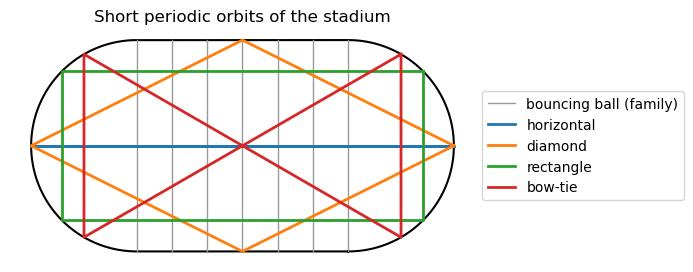

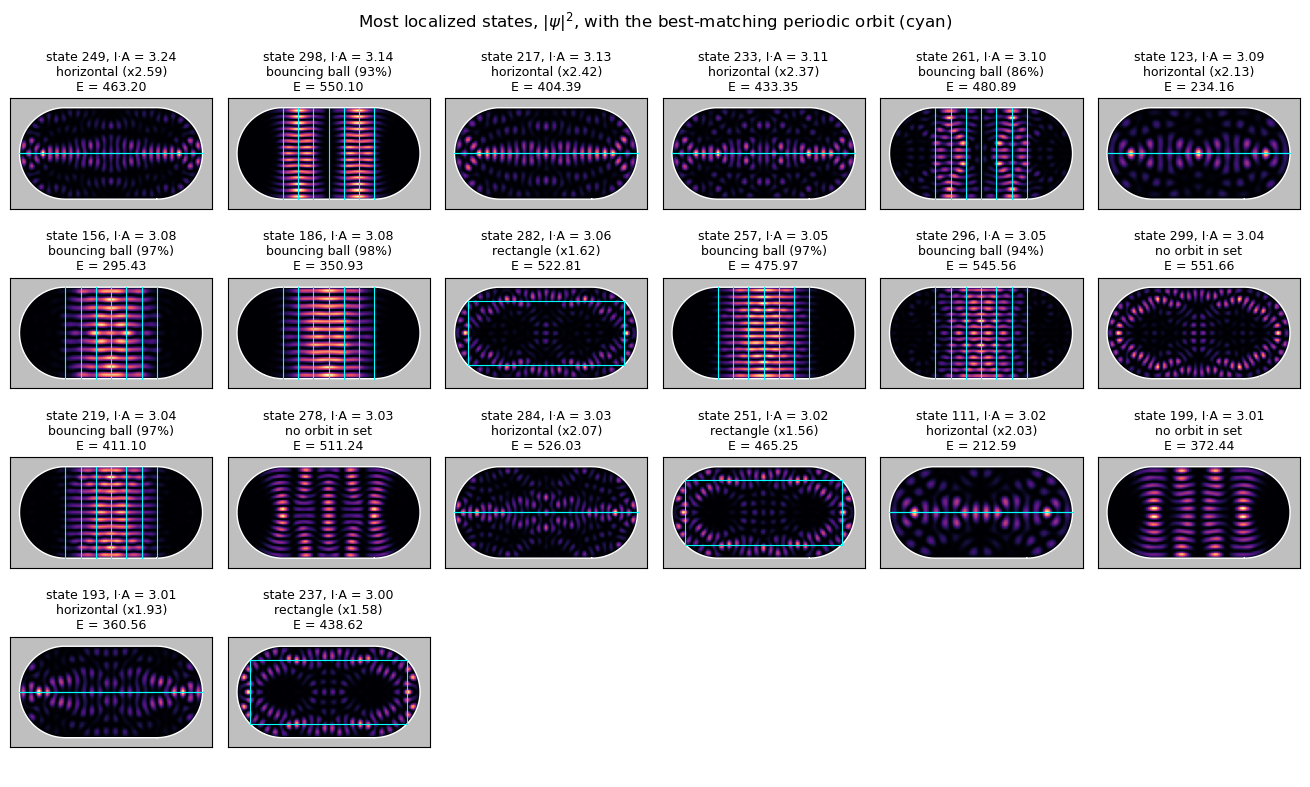

In [9]:
# Distance from every grid point to the orbit (minimum over its straight segments)
def dist_to_orbit(V):
    V = np.asarray(V, float)
    P = np.c_[Xs.ravel(), Ys.ravel()]
    d = np.full(len(P), np.inf)
    for p, q in zip(V, np.roll(V, -1, 0)):
        t = np.clip((P - p) @ (q - p) / ((q - p) @ (q - p)), 0, 1)
        d = np.minimum(d, np.linalg.norm(P - p - t[:, None] * (q - p), axis=1))
    return d.reshape(Xs.shape)

dist = {name: dist_to_orbit(V) for name, V in orbits_s.items()}
straight = mask_s & (abs(Xs - x0) < a / 2)

# Probability in the half-wavelength tube around the orbit / tube's share of the area (1 = evenly spread)
def enhancement(p, E, name):
    tube = mask_s & (dist[name] < np.pi / np.sqrt(E))
    return (p**2 * tube).sum() * h_s**2 / (tube.sum() / mask_s.sum())

overlay, labels = [], []
for i in top:
    p_bb = (psi_s[i]**2 * straight).sum() * h_s**2
    enh = {name: enhancement(psi_s[i], E_s[i], name) for name in orbits_s}
    best = max(enh, key=enh.get)
    if p_bb > 0.8:
        overlay.append(bouncing_ball); tag = f"bouncing ball ({p_bb:.0%})"
    elif enh[best] > 1.5:
        overlay.append(closed(orbits_s[best])); tag = f"{best} (x{enh[best]:.2f})"
    else:
        overlay.append(None); tag = "no orbit in set"
    labels.append(f"state {i + 1}, I·A = {ipr[i]:.2f}\n{tag}")

# The orbit set on its own
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(*wall_s, "k", lw=1.5)
ax.plot(*bouncing_ball, color="0.6", lw=1, label="bouncing ball (family)")
for name, V in orbits_s.items():
    ax.plot(*closed(V), lw=2, label=name)
ax.set_aspect("equal"); ax.axis("off"); ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Short periodic orbits of the stadium")
plt.show()

plot_wavefunction(Xs, Ys, psi_s[top], E_s[top], labels, density=True, mask=mask_s, wall=wall_s, orbits=overlay,
                  suptitle=r"Most localized states, $|\psi|^2$, with the best-matching periodic orbit (cyan)")

quarter stadium: fitted c1 = 0.1498,  Weyl A/4pi = 0.1421
rectangle:       fitted c1 = 0.1362,  Weyl A/4pi = 0.1288
quarter stadium        P(s < 0.25) = 0.067
full stadium           P(s < 0.25) = 0.173
rectangle (numerical)  P(s < 0.25) = 0.215
rectangle (analytic)   P(s < 0.25) = 0.221
4 mixed Wigner (theory) P(s < 0.25) = 0.178


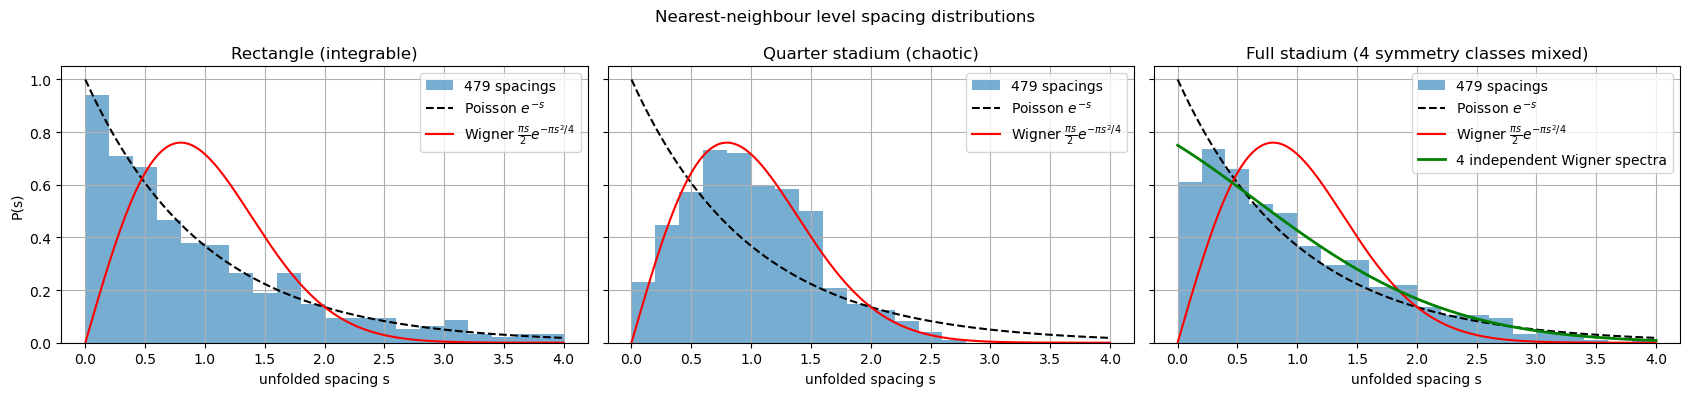

In [10]:
# Eigenvalue spacing, we unfold the eigenvalues such that the mean spacing is 1, then plot the histogram of spacings.
# If the shape is integrable (rectangle), the spacings are Poisson-distributed, while if it is chaotic (stadium), they follow the Wigner surmise.
#
# - Stadium: solve a QUARTER stadium with psi = 0 on the two symmetry axes. The full stadium's spectrum is four
#   independent symmetry classes laid on top of each other, which would fake Poisson-like statistics.
#   The full stadium is also solved below to show exactly that.
# - Rectangle: the golden-ratio box from above (irrational aspect ratio, so no n^2 + m^2 accidental degeneracies).
# - Unfolding: fit the smooth counting function N(E) = c1 E + c2 sqrt(E) + c0 (Weyl's form) and map E_i -> N(E_i).
#   Fitting instead of using the exact Weyl coefficients absorbs the slow O((kh)^2) drift of the finite-difference levels.
h_q, k_q, skip = 0.01, 500, 20        # skip the lowest levels, which are not yet in the semiclassical regime

def unfolded_spacings(E):
    M = np.c_[E, np.sqrt(E), np.ones_like(E)]
    coef = np.linalg.lstsq(M, np.arange(1, len(E) + 1), rcond=None)[0]
    s = np.diff(M[skip:] @ coef)
    return s / s.mean(), coef

Xq, Yq = grid(a / 2 + r, r, h_q)
E_quarter, _ = solve(stadium(Xq, Yq, a, r, 0, 0) & (Xq > 0) & (Yq > 0), h_q, k_q)
Xr, Yr = grid(Lx, Ly, h_q)
E_rect, _ = solve(rectangle(Xr, Yr, Lx, Ly), h_q, k_q)

# Full stadium (all four symmetry classes mixed), on the h = 0.015 grid used above: 500 levels only reach
# E ~ 900 here, since the area is 4x the quarter's, so the grid resolves them at least as well
E_full, _ = solve(mask_s, h_s, k_q)

s_stad, coef_stad = unfolded_spacings(E_quarter)
s_full, _ = unfolded_spacings(E_full)
s_rect, coef_rect = unfolded_spacings(E_rect)
s_exact, _ = unfolded_spacings(energy(Lx, Ly, k_q, nmax=200)[0])   # analytic rectangle levels, as a reference

# Check: the fitted area coefficient should be close to Weyl's A/4pi (a few % high from the grid's drift)
A_q = a * r / 2 + np.pi * r**2 / 4
print(f"quarter stadium: fitted c1 = {coef_stad[0]:.4f},  Weyl A/4pi = {A_q / (4 * np.pi):.4f}")
print(f"rectangle:       fitted c1 = {coef_rect[0]:.4f},  Weyl A/4pi = {Lx * Ly / (4 * np.pi):.4f}")

# Level repulsion in one number: fraction of spacings below 0.25 (Poisson 0.221, Wigner 0.048)
for name, s in [("quarter stadium", s_stad), ("full stadium", s_full), ("rectangle (numerical)", s_rect), ("rectangle (analytic)", s_exact)]:
    print(f"{name:<22} P(s < 0.25) = {(s < 0.25).mean():.3f}")

# Prediction for four independent Wigner spectra, each holding 1/4 of the levels: the probability of an empty
# interval of length s multiplies, E(s) = g(s)^4 with g = erfc(sqrt(pi) s / 8), and P(s) = E''(s).
# With g' = -exp(-pi s^2/64)/4 and g'' = (pi s/128) exp(-pi s^2/64): E'' = 12 g^2 g'^2 + 4 g^3 g''.  P(0) = 1 - 4 (1/4)^2 = 3/4.
from scipy.special import erfc
s = np.linspace(0, 4, 400)
poisson, wigner = np.exp(-s), np.pi * s / 2 * np.exp(-np.pi * s**2 / 4)
four = lambda s: (erfc(np.sqrt(np.pi) * s / 8), -np.exp(-np.pi * s**2 / 64) / 4, np.pi * s / 128 * np.exp(-np.pi * s**2 / 64))
g, g1, g2 = four(s)
four_wigner = 12 * g**2 * g1**2 + 4 * g**3 * g2
g, g1, _ = four(0.25)
print(f"{'4 mixed Wigner (theory)':<22} P(s < 0.25) = {1 + 4 * g**3 * g1:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for ax, sp_, name in zip(axes, [s_rect, s_stad, s_full],
                         ["Rectangle (integrable)", "Quarter stadium (chaotic)", "Full stadium (4 symmetry classes mixed)"]):
    ax.hist(sp_, bins=np.arange(0, 4.01, 0.2), density=True, alpha=0.6, label=f"{len(sp_)} spacings")
    ax.plot(s, poisson, "k--", label=r"Poisson $e^{-s}$")
    ax.plot(s, wigner, "r", label=r"Wigner $\frac{\pi s}{2}e^{-\pi s^2/4}$")
    ax.set(xlabel="unfolded spacing s", title=name)
    ax.legend(); ax.grid()
axes[2].plot(s, four_wigner, "g", lw=2, label="4 independent Wigner spectra")
axes[2].legend()
axes[0].set_ylabel("P(s)")
fig.suptitle("Nearest-neighbour level spacing distributions", fontsize=12)
fig.tight_layout()
plt.show()